# GeologyManager class
This notebook display how the GeologyManager() class works with a 2D case.

In [1]:
import pykasso as pk
import numpy   as np
import matplotlib.pyplot as plt

In [2]:
# First create grid object
x0, y0, z0 = 0, 0, 0
nx, ny, nz = 10, 10, 1
dx, dy, dz = 10, 10, 10

grid = pk.Grid(x0,y0,z0,nx,ny,nz,dx,dy,dz)

# Then create geology manager
geology = pk.GeologyManager(grid)

## Add some data
- Geology 
- Faults
- Fractures
- Topography
- Orientation

### set_data_null()
Available for 'geology', 'faults', 'fractures', 'topography', 'orientationx' and 'orientationy'. <br>
Return a numpy array of dimension (nx, ny, nz) full of zeros. <br>
Return a numpy array of dimension (nx, ny) for 'topography', 'orientationx', 'orientationy'.

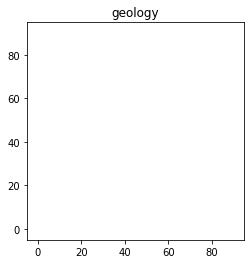

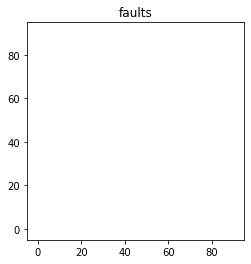

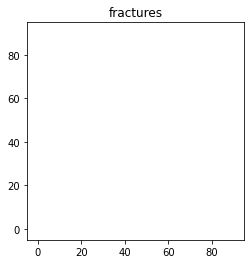

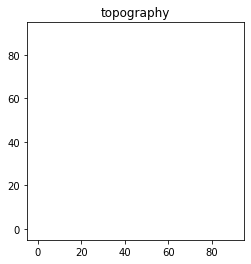

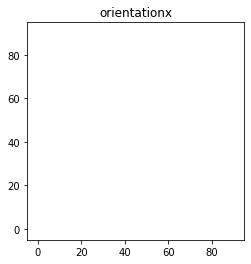

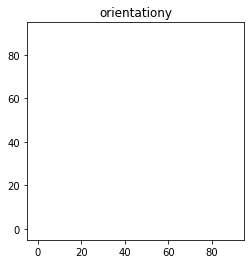

In [3]:
data_labels = ['geology', 'faults', 'fractures', 'topography', 'orientationx', 'orientationy']

for data_label in data_labels:
    geology.set_data_null(data_label)
    geology.show(data=data_label)

### set_data_from_csv()
Available for 'geology', 'topography', 'surface' (orientation), 'faults' and 'fractures'. <br>
The delemiter is a comma (e.g. ','). <br>
If nz > 1, the layer is horizontally repeated.

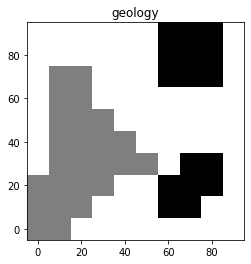

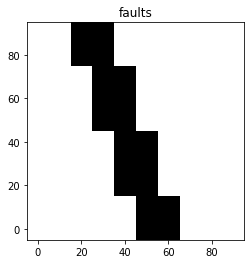

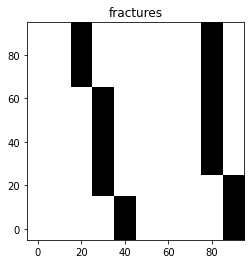

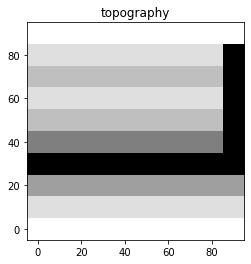

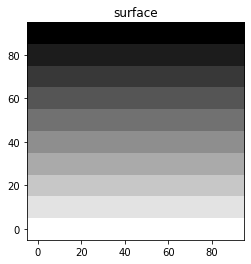

In [4]:
data_labels = ['geology', 'faults', 'fractures', 'topography', 'surface']

for data_label in data_labels:
    geology.set_data_from_csv(data_label, "inputs/csv/{}.csv".format(data_label))
    geology.show(data=data_label)

### set_data_from_gslib()
Available for 'geology', 'faults' and 'fractures'. <br>
Only one column of data is accepted

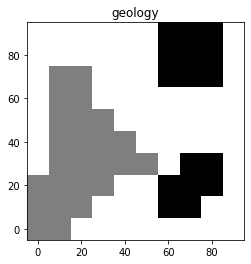

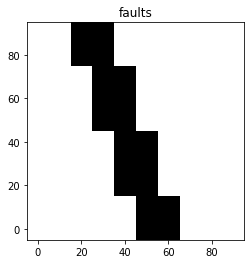

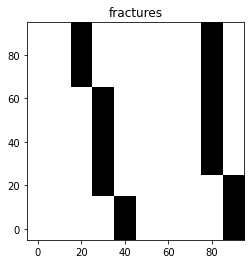

In [5]:
data_labels = ['geology', 'faults', 'fractures']

for data_label in data_labels:
    geology.set_data_from_gslib(data_label, "inputs/gslib/{}.gslib".format(data_label))
    geology.show(data=data_label)

### set_data_from_image()
Available for 'geology', 'faults' and 'fractures'.<br>
Work only with binary image (e.g. black&white image).<br>
The size of the image should be the same that the size of the grid.<br>
If nz > 1, the layer is horizontally repeated.<br>
set_data_from_image() usage is not recommended, it should be used only for quick testing.<br>

- [???] geology   : white = 0 = aquifer / black = 1 = aquitard
- [???] faults    : white = 0 = no faults / black = 1 = faults
- [???] fractures : white = 0 = no fractures / black = 1 = fractures

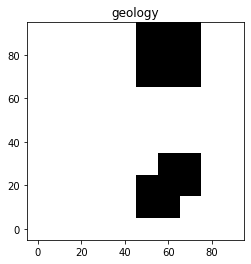

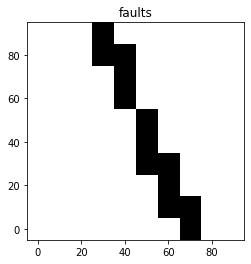

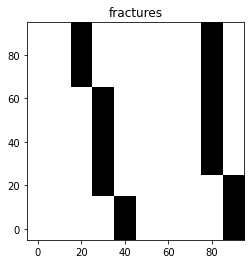

In [6]:
data_labels = ['geology', 'faults', 'fractures']

for data_label in data_labels:
    geology.set_data_from_image(data_label, "inputs/img/{}.png".format(data_label))
    geology.show(data=data_label)

### Topography and Orientations

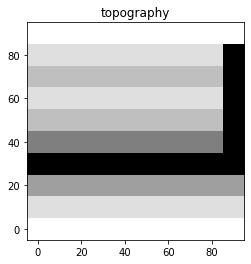

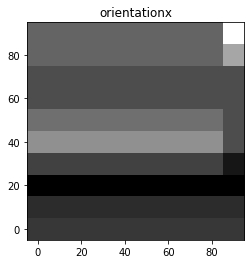

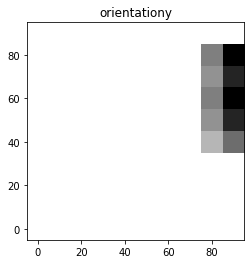

In [7]:
# If 'topography' is given, then you can calculate orientation on x and y with generate_orientations()
geology.set_data_from_csv("topography", "inputs/csv/topography.csv")
surface = geology.data["topography"]["data"]
geology.generate_orientations(surface)

# Plot orientations
geology.show(data="topography")
geology.show(data="orientationx")
geology.show(data="orientationy")

### Generate Fractures

In [8]:
# Create a larger grid 
x0, y0, z0 = 0, 0, 0
nx, ny, nz = 1000, 1000, 1
dx, dy, dz = 10, 10, 10

grid = pk.Grid(x0,y0,z0,nx,ny,nz,dx,dy,dz)

# Set a seed (for reproducibility)
seed = 1
np.random.seed(seed)

# Then create geology manager
geology = pk.GeologyManager(grid)

In [9]:
# Fracture generation settings
fractures_densities = [0.000001, 0.000001]
fractures_alpha = [2, 2]
fractures_min_orientation = [0,   90]
fractures_max_orientation = [10, 100]
fractures_min_dip = [0, 0]
fractures_max_dip = [1, 1]
fractures_min_length = [2000  , 1000]
fractures_max_length = [10000,  4000]

In [10]:
# Generate fractures
geology.generate_fractures(fractures_densities, fractures_alpha, 
                           fractures_min_orientation, fractures_max_orientation,
                           fractures_min_dip,fractures_max_dip,
                           fractures_min_length, fractures_max_length)

In [11]:
# Fractures are stored in this list
geology.fractures

[[id:0, fam.:0, x:-5002.71, y:1041.65, z:-7.06, rad:1079.76, or.:0.07, dip.:0.0, n:(-0.07,-1.0,-0.0)] ,
 [id:1, fam.:0, x:5771.33, y:3378.89, z:3.7, rad:1195.55, or.:0.16, dip.:0.0, n:(-0.16,-0.99,-0.0)] ,
 [id:2, fam.:0, x:-2197.26, y:-1042.97, z:6.01, rad:4436.74, or.:0.11, dip.:0.0, n:(-0.11,-0.99,-0.0)] ,
 [id:3, fam.:0, x:12887.13, y:-3304.12, z:-9.22, rad:1157.23, or.:0.12, dip.:0.0, n:(-0.12,-0.99,-0.0)] ,
 [id:4, fam.:0, x:8832.54, y:1305.31, z:3.73, rad:3009.33, or.:0.09, dip.:0.0, n:(-0.09,-1.0,-0.0)] ,
 [id:5, fam.:0, x:9958.31, y:603.88, z:5.79, rad:1090.01, or.:0.05, dip.:0.0, n:(-0.05,-1.0,-0.0)] ,
 [id:6, fam.:0, x:750.51, y:-2404.43, z:-9.61, rad:2188.51, or.:0.07, dip.:0.0, n:(-0.07,-1.0,-0.0)] ,
 [id:7, fam.:0, x:-3937.75, y:6477.35, z:-7.07, rad:1891.95, or.:0.01, dip.:0.0, n:(-0.01,-1.0,-0.0)] ,
 [id:8, fam.:0, x:8883.0, y:3278.59, z:-9.0, rad:1750.45, or.:0.16, dip.:0.0, n:(-0.16,-0.99,-0.0)] ,
 [id:9, fam.:0, x:6726.1, y:13063.04, z:-7.25, rad:1125.39, or.:0.11, d

In [12]:
# Then rasterize the fractures
frac = geology.rasterize_fracture_network()

Rasterizing: 100%|█████████████████████████████████████████████████████████████████| 827/827 [00:00<00:00, 8271.15it/s]


### Visualize Fractures

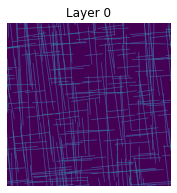

In [13]:
# Plot the fractures for eah z level
import matplotlib.pyplot as plt
for z in range(grid.nz):    
    plt.figure( figsize=(3,3) )
    plt.imshow(frac[:,:,z], origin='lower')
    plt.title('Layer ' + str(z))
    plt.axis('off')
    plt.show()

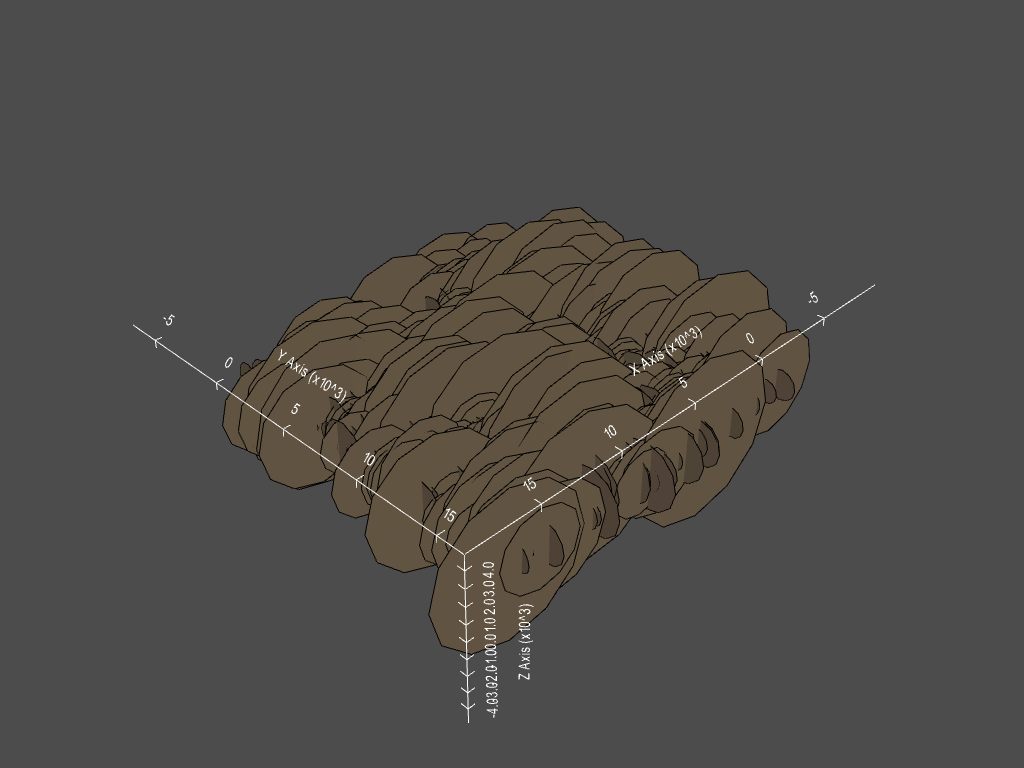

[(47895.28257126466, 47768.826760717784, 42929.634377905284),
 (4961.296875, 4834.841064453125, -4.351318359375),
 (0.0, 0.0, 1.0)]

In [14]:
# Visualize fractures with pyvista [conda install -c conda-forge pyvista]
import pyvista as pv
frac = geology.fractures

p = pv.Plotter()
for f in frac:
    x, y, z = f.get_position()
    a, b, c = f.get_normal()
    pol = pv.Polygon(center=(x, y, z), radius=f.radius, normal=(a, b, c), n_sides=12)
    p.add_mesh(pol, color="tan", show_edges=True)
p.show_bounds()

p.show()